In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [ ]:
pff = pd.read_csv('pffScoutingData.csv')
plays = pd.read_csv('plays.csv')
week4 = pd.read_csv('week4.csv')
week4.columns

Index(['gameId', 'playId', 'nflId', 'frameId', 'time', 'jerseyNumber', 'team',
       'playDirection', 'x', 'y', 's', 'a', 'dis', 'o', 'dir', 'event'],
      dtype='object')

## Counting number of defensive players on the LOS to capture defensive front tendencies.
Non-DBs who are within 1.5 yards of the LOS are considered as part of the defensive front


In [ ]:
# filter to only frames when the ball is snapped
ball_snaps = week4[(week4['event'] == 'ball_snap') ]
temp = ball_snaps.merge(pff[['gameId', 'playId', 'nflId', 'pff_positionLinedUp']], on=['gameId', 'playId', 'nflId'], how='left')
temp = temp.merge(plays[['gameId', 'playId', 'possessionTeam', 'defensiveTeam']], on=['gameId', 'playId'], how='left')
temp

# get ball location on frameId == 1
ball_locations = week4[(week4['frameId'] == 1) & (week4['team'] == 'football')]
ball_locations = ball_locations.drop_duplicates(subset=['playId'])[['gameId', 'playId', 'x']].rename(columns={'x':'x_ball'})

temp = temp.merge(ball_locations, on=['gameId', 'playId'], how='left')

# non-DBs who are within 1.5 yards of the LOS are considered as part of the defensive front
temp['on_los'] = ((temp['x'] - temp['x_ball']).abs() <= 1.5) & (temp['team'] == temp['defensiveTeam']) & (~temp['pff_positionLinedUp'].str.contains("CB", na=True))
players_on_los = temp[(temp['on_los'])]
defenders_on_los = players_on_los.groupby(['gameId','playId']).count()[['nflId']].reset_index().rename(columns={'nflId': 'defendersOnLOS'})

# (week4['event'] == 'ball_snap')

In [ ]:
defenders_on_los = defenders_on_los.merge(plays[['gameId', 'playId', 'down']], on=['gameId', 'playId'], how='left')
defenders_on_los['defendersOnLOS'].value_counts()


,count
defendersOnLOS,
4,562
5,270
6,82
3,35
7,16
2,5
8,4
1,1


Create pie charts

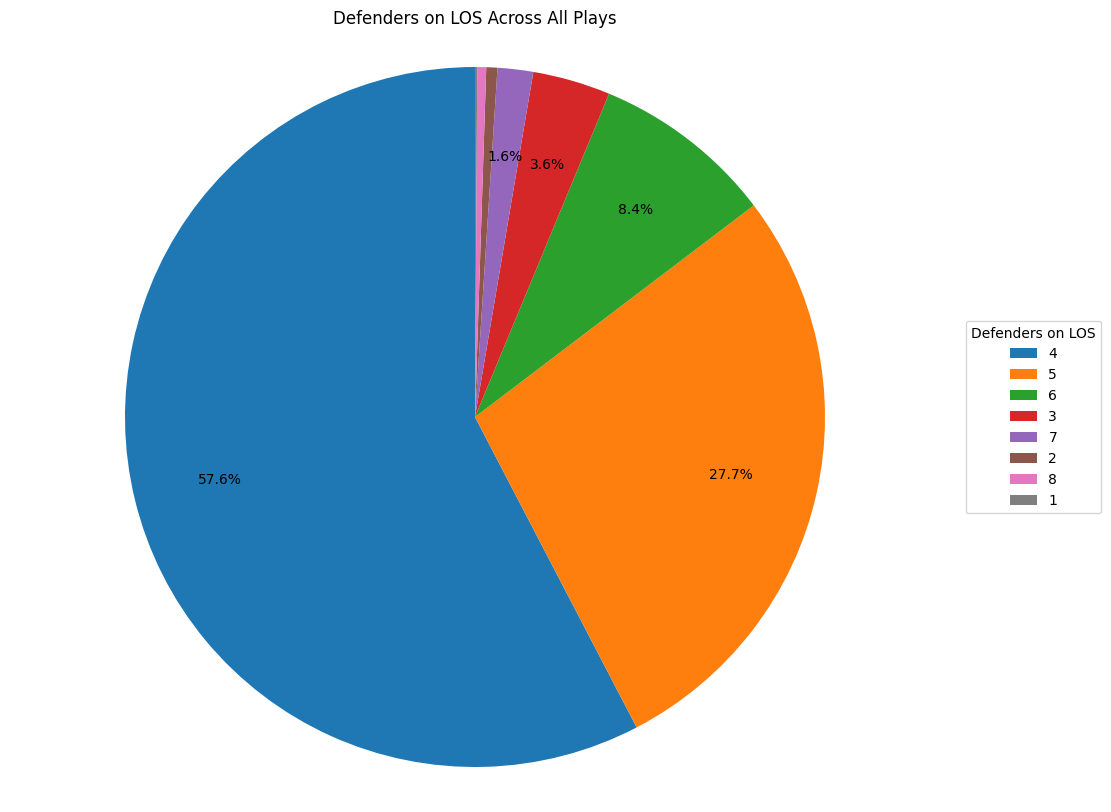

In [ ]:
import matplotlib.pyplot as plt

vc = defenders_on_los['defendersOnLOS'].value_counts()   # Series: index=labels, values=counts

# plt.figure(figsize=(10,8))
# plt.pie(vc.values, labels=vc.index, autopct="%1.1f%%", startangle=90)
# plt.axis("equal")  # keeps it circular
# plt.show()

fig, ax = plt.subplots(figsize=(12,10))
wedges, _, _ = ax.pie(vc.values, autopct=lambda func: f"{func:.1f}%" if func >= 1 else "", startangle=90, pctdistance=0.75)
ax.axis("equal")
ax.legend(wedges, vc.index, title="Defenders on LOS", loc="center left", bbox_to_anchor=(1.02, 0.5))
plt.title('Defenders on LOS Across All Plays')
plt.show()


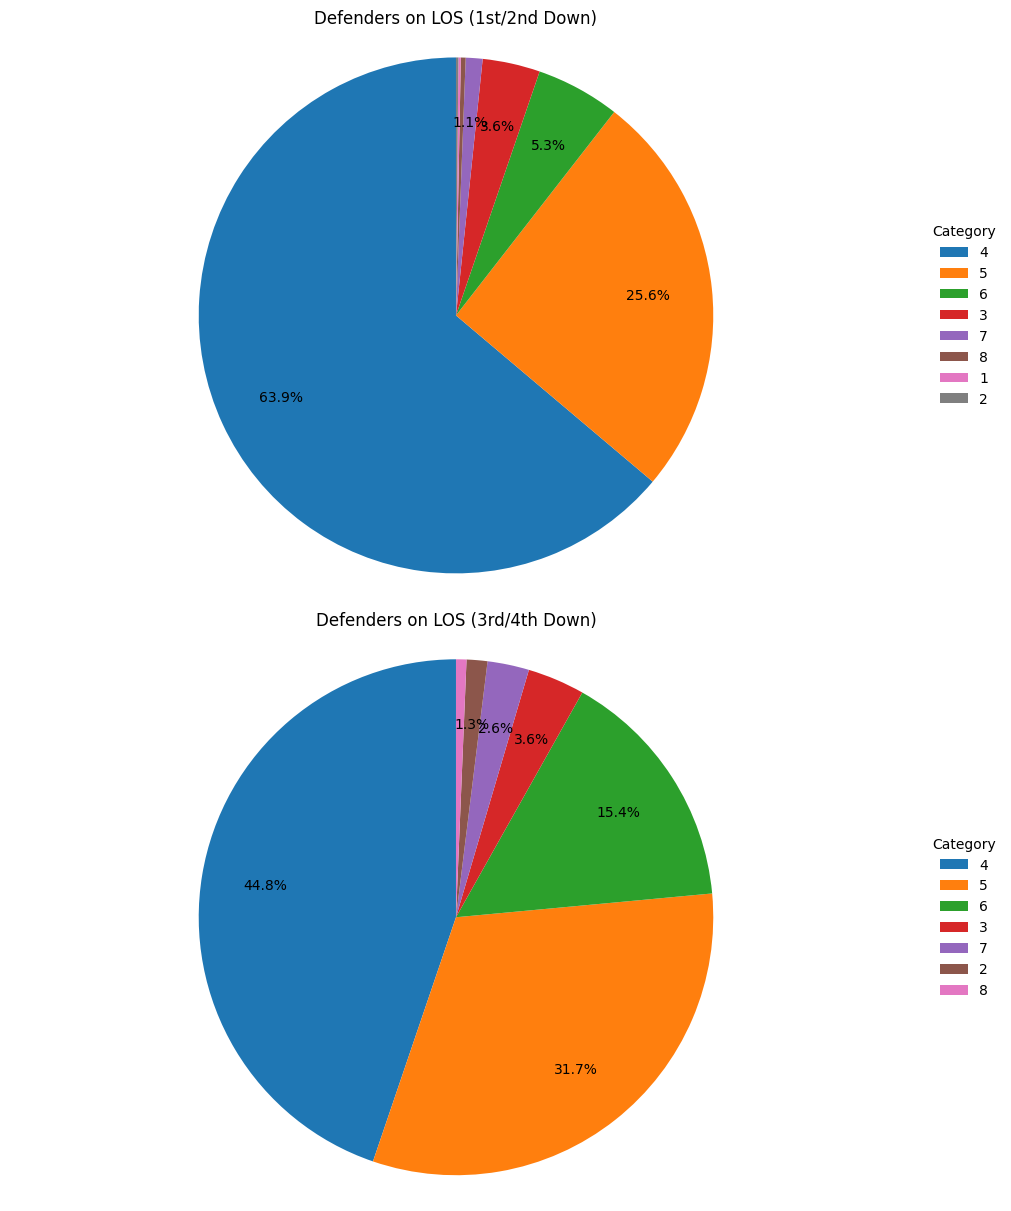

In [ ]:
import matplotlib.pyplot as plt

vc = defenders_on_los[defenders_on_los['down'] == 1]['defendersOnLOS'].value_counts()   # Series: index=labels, values=counts

# plt.figure(figsize=(10,8))
# plt.pie(vc.values, labels=vc.index, autopct="%1.1f%%", startangle=90)
# plt.axis("equal")  # keeps it circular
# plt.show()

# fig, ax = plt.subplots(3, 1, figsize=(10,16))
# wedges, _, _ = ax.pie(vc.values, autopct=lambda func: f"{func:.1f}%" if func >= 1 else "", startangle=90, pctdistance=0.75)
# ax.axis("equal")
# ax.legend(wedges, vc.index, title="Defenders on LOS", loc="center left", bbox_to_anchor=(1.02, 0.5))
# plt.title('Defenders on LOS Across All Plays')
# plt.show()


vc1 = defenders_on_los[(defenders_on_los['down'] == 1) | (defenders_on_los['down'] == 2)]['defendersOnLOS'].value_counts()
vc2 = defenders_on_los[(defenders_on_los['down'] == 3) | (defenders_on_los['down'] == 4)]['defendersOnLOS'].value_counts()
# vc3 = defenders_on_los[defenders_on_los['down'] == 3]['defendersOnLOS'].value_counts()

vcs = [vc1, vc2]
titles = ["Defenders on LOS (1st/2nd Down)", "Defenders on LOS (3rd/4th Down)"]

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 12), constrained_layout=True)

for ax, vc, title in zip(axes, vcs, titles):
    wedges, _, _ = ax.pie(vc.values, autopct=lambda func: f"{func:.1f}%" if func >= 1 else "", startangle=90, pctdistance=0.75)
    ax.set_title(title)
    ax.axis("equal")
    ax.legend(
        wedges, vc.index,
        title="Category",
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=False
    )

plt.show()
